In [ ]:
from google.colab import files

files.download("bearing_features.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import kurtosis

window_size = 1200
step_size = 600  # 50% overlap

rows = []

for condition, signal in signals.items():

    for start in range(
        0, len(signal) - window_size + 1, step_size
    ):
        x = signal[start:start + window_size].astype(float)

        rms = np.sqrt(np.mean(x**2))
        peak = np.max(np.abs(x))

        rows.append({
            "RMS": rms,
            "Peak": peak,
            "Crest_Factor": peak / rms if rms else 0,
            "Kurtosis": kurtosis(
                x, fisher=False, bias=False
            ),
            "Condition": condition
        })

features_df = pd.DataFrame(rows)

print("Dataset shape:", features_df.shape)
print(features_df.head())
print("\nSamples per class:")
print(features_df["Condition"].value_counts())

features_df.to_csv("bearing_features.csv", index=False)

Dataset shape: (606, 5)
        RMS      Peak  Crest_Factor  Kurtosis Condition
0  0.290593  1.382973      4.759137  5.451564    Faulty
1  0.285100  1.382973      4.850829  5.614846    Faulty
2  0.281291  1.482708      5.271079  5.654983    Faulty
3  0.294132  1.482708      5.040956  5.808908    Faulty
4  0.292168  1.203807      4.120256  5.311787    Faulty

Samples per class:
Condition
Healthy    405
Faulty     201
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import kurtosis

results = []

for name, signal in signals.items():

    # Use the complete recording
    x = signal.astype(float)

    # Calculate features
    rms = np.sqrt(np.mean(x**2))
    peak = np.max(np.abs(x))
    crest_factor = peak / rms
    kurt = kurtosis(x, fisher=False, bias=False)

    results.append({
        "Condition": name,
        "RMS": rms,
        "Peak": peak,
        "Crest_Factor": crest_factor,
        "Kurtosis": kurt
    })

# Display results
df = pd.DataFrame(results)
print(df.round(4).to_string(index=False))

# Save the results
df.to_csv("bearing_feature_summary.csv", index=False)

Condition    RMS   Peak  Crest_Factor  Kurtosis
   Faulty 0.2915 1.7390        5.9653    5.3960
  Healthy 0.0738 0.3113        4.2196    2.7643


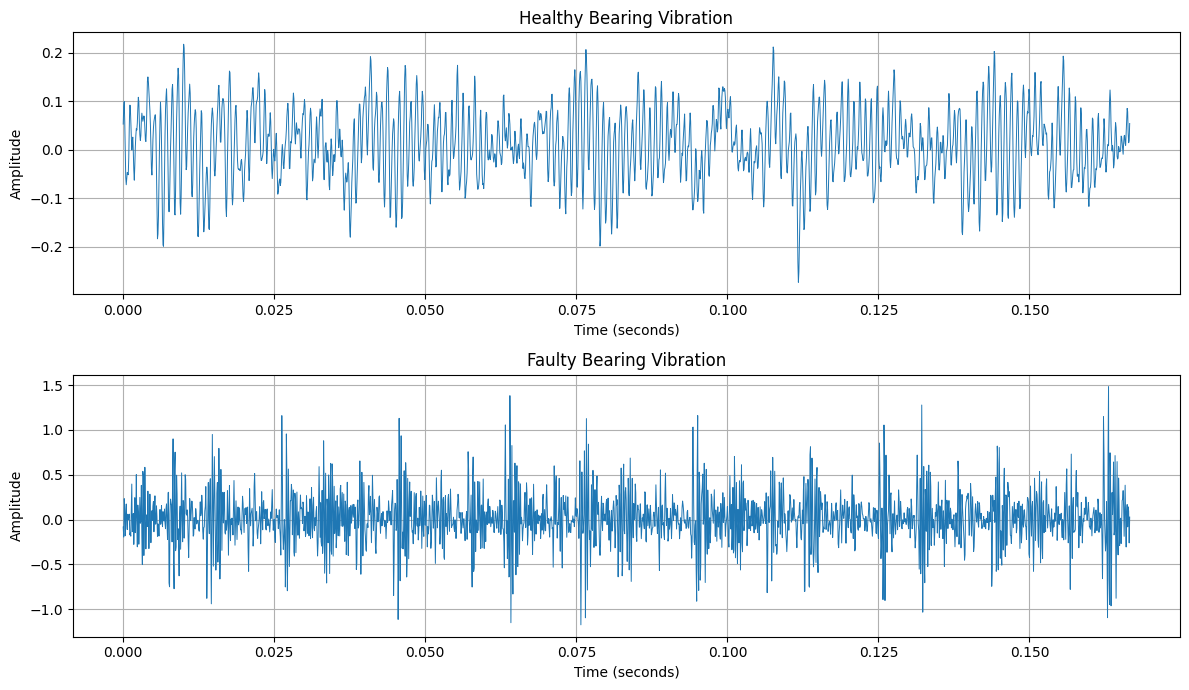

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

signals = {}

for filename in uploaded.keys():
    data = loadmat(filename)

    # Identify the drive-end vibration variable
    key = [k for k in data if k.endswith("_DE_time")][0]
    signal = data[key].flatten()

    # Identify healthy and faulty recordings
    if "normal" in filename.lower():
        signals["Healthy"] = signal
    else:
        signals["Faulty"] = signal

# Plot the first 2000 samples
N = 2000
fs = 12000  # Sampling frequency: 12 kHz

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

for ax, name in zip(axes, ["Healthy", "Faulty"]):
    signal = signals[name][:N]
    time = np.arange(len(signal)) / fs

    ax.plot(time, signal, linewidth=0.7)
    ax.set_title(f"{name} Bearing Vibration")
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Amplitude")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.io import loadmat

for filename in uploaded.keys():
    data = loadmat(filename)

    print("\nFILE:", filename)

    for key, value in data.items():
        if not key.startswith("__"):
            print(key, value.shape)


FILE: 12k Drive end bearing fault data (motorspeed-1797rpm&motorload-0hp).mat
X105_DE_time (121265, 1)
X105_FE_time (121265, 1)
X105_BA_time (121265, 1)
X105RPM (1, 1)

FILE: normal baseline data(motorspeed-1797&motorload-0hp).mat
X097_DE_time (243938, 1)
X097_FE_time (243938, 1)
X097RPM (1, 1)


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 12k Drive end bearing fault data (motorspeed-1797rpm&motorload-0hp).mat to 12k Drive end bearing fault data (motorspeed-1797rpm&motorload-0hp).mat
Saving normal baseline data(motorspeed-1797&motorload-0hp).mat to normal baseline data(motorspeed-1797&motorload-0hp).mat
